In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# UNIVERSAL DATASET LOADER
# =============================

try:
    # POWER BI
    df = dataset.copy()
except:
    # GOOGLE COLAB
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_excel(file_name)

# =============================
# CLEAN COLUMN NAMES
# =============================

df.columns = df.columns.str.strip()

# =============================
# CLEAN CGPA COLUMN
# =============================

cgpa_col = 'Current CGPA'
df[cgpa_col] = pd.to_numeric(df[cgpa_col], errors='coerce')

# =============================
# CREATE CGPA BANDS
# =============================

bins = [0, 2.5, 3.0, 3.5, 4.0]
labels = ['Below 2.5', '2.5–3.0', '3.0–3.5', '3.5–4.0']

df['CGPA Band'] = pd.cut(df[cgpa_col], bins=bins, labels=labels)



Saving FJWU_Data_Fixed_Final (2).xlsx to FJWU_Data_Fixed_Final (2).xlsx


**GRAPH 1 — HEATMAP: CGPA vs JOB READINESS**

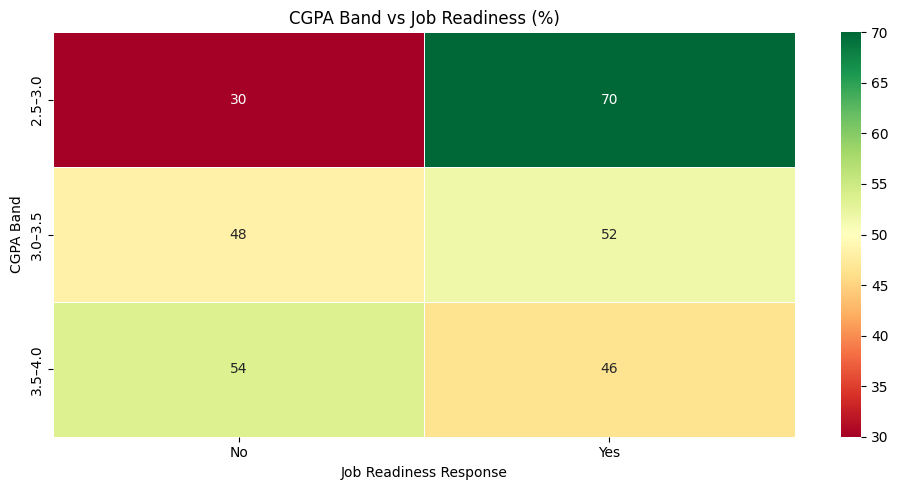

In [2]:
# =============================
# JOB READINESS COLUMN
# =============================

job_col = 'Respond to the following Questions. [If you had to judge yourself honestly, do you think you are job-ready after graduation ??]'

# =============================
# CROSS TAB (PERCENTAGE)
# =============================

heatmap_data = pd.crosstab(
    df['CGPA Band'],
    df[job_col],
    normalize='index'
) * 100

# =============================
# HEATMAP (SEABORN)
# =============================

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title('CGPA Band vs Job Readiness (%)')
plt.xlabel('Job Readiness Response')
plt.ylabel('CGPA Band')

plt.tight_layout()
plt.show()

**GRAPH 2 — HEATMAP: CGPA vs UNIVERSITY PREPARATION**

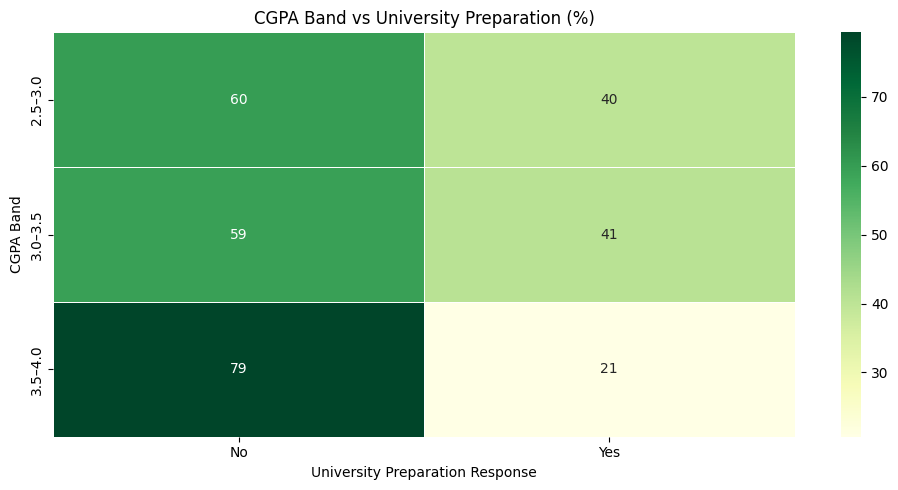

In [3]:
# =============================
# UNIVERSITY PREPARATION COLUMN
# =============================

prep_col = 'Respond to the following Questions. [Do you feel university has prepared you for industry?]'

# =============================
# CROSS TAB (PERCENTAGE)
# =============================

heatmap_data = pd.crosstab(
    df['CGPA Band'],
    df[prep_col],
    normalize='index'
) * 100

# =============================
# HEATMAP (SEABORN)
# =============================

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGn",
    linewidths=0.5
)

plt.title('CGPA Band vs University Preparation (%)')
plt.xlabel('University Preparation Response')
plt.ylabel('CGPA Band')

plt.tight_layout()
plt.show()

**GRAPH 3 — SUNBURST CHART: SKILLS VS CGPA MINDSET**

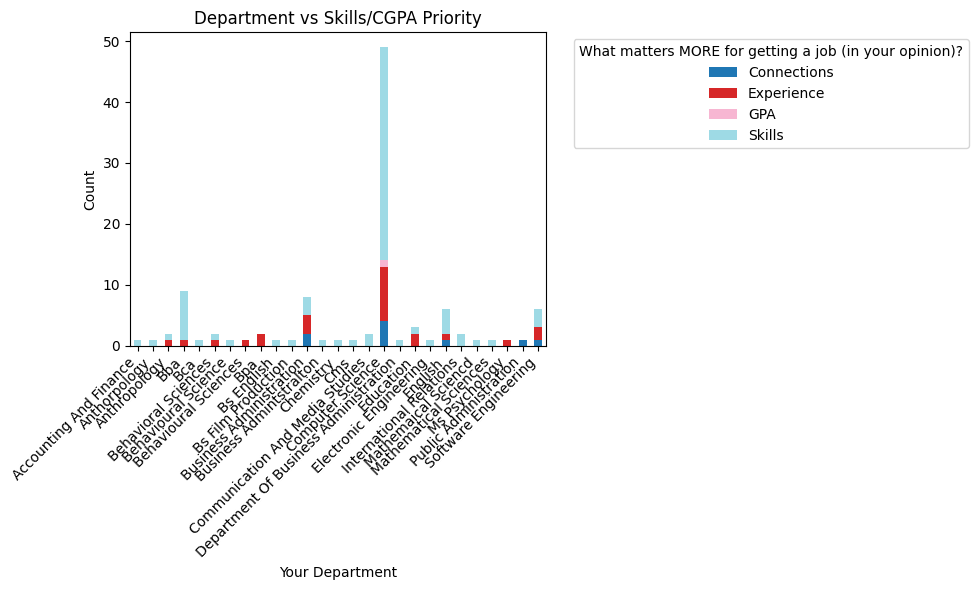

In [4]:
skill_col = 'What matters MORE for getting a job (in your opinion)?'
dept_col = 'Your Department:'

# =============================
# CLEAN DATA (optional but safe)
# =============================

df = df.dropna(subset=[skill_col, dept_col])

# =============================
# CREATE CROSS TAB (FOR STACKED BAR)
# =============================

stack_data = pd.crosstab(df[dept_col], df[skill_col])

# =============================
# PLOT (STACKED BAR CHART)
# =============================

stack_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'
)

plt.title('Department vs Skills/CGPA Priority')
plt.xlabel('Your Department')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')
plt.legend(title=skill_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**GRAPH 4 — TREEMAP: SKILLS STUDENTS ARE LACKING**

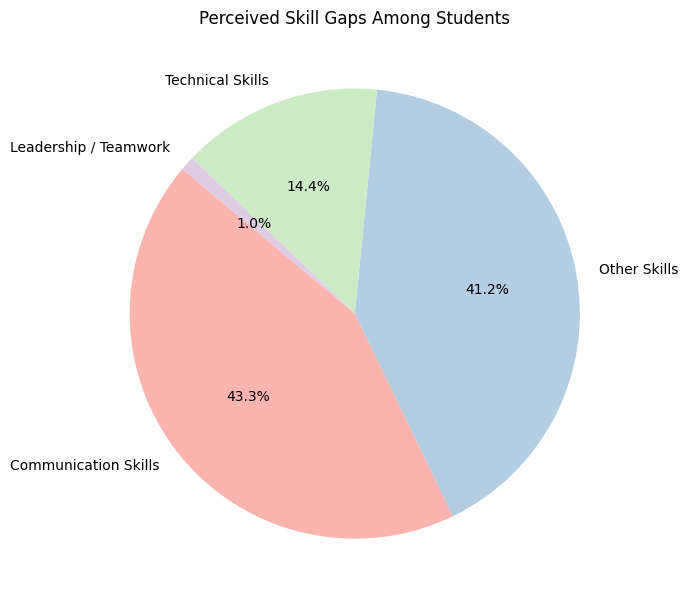

In [5]:


df.columns = df.columns.str.strip()

# =============================
# COLUMN
# =============================

skill_col = 'What skills do you think you are lacking for a job?'

# =============================
# CLEAN TEXT
# =============================

df2 = df[skill_col].dropna().astype(str).str.lower()

# =============================
# CATEGORIZATION FUNCTION (FIXED)
# =============================

def categorize(text):
    if any(x in text for x in ["communication", "english", "speaking", "confidence"]):
        return "Communication Skills"

    elif any(x in text for x in ["coding", "programming", "technical", "it", "software"]):
        return "Technical Skills"

    elif any(x in text for x in ["time", "management", "organizing"]):
        return "Time Management"

    elif any(x in text for x in ["leadership", "team", "group"]):
        return "Leadership / Teamwork"

    else:
        return "Other Skills"

df2 = df2.apply(categorize)

# =============================
# COUNT VALUES
# =============================

counts = df2.value_counts()

# =============================
# PIE CHART (MATPLOTLIB)
# =============================

plt.figure(figsize=(7, 7))

colors = plt.cm.Pastel1(range(len(counts)))  # optional nicer colors

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title("Perceived Skill Gaps Among Students")

plt.tight_layout()
plt.show()

**GRAPH 5 — STACKED BAR: DEPARTMENT vs INTERNSHIP EXPERIENCE**

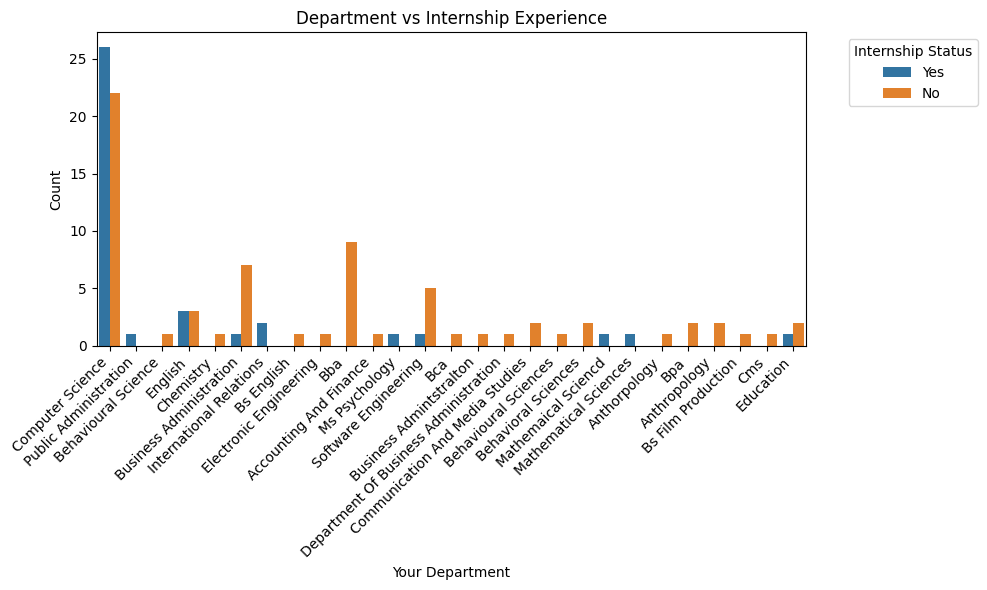

In [6]:
dept_col = 'Your Department:'
intern_col = 'Respond to the following Questions. [Completed any internship?]'

# =============================
# CLEAN DATA
# =============================

df = df.dropna(subset=[dept_col, intern_col])

# =============================
# PLOT (GROUPED BAR CHART)
# =============================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x=dept_col,
    hue=intern_col
)

plt.title("Department vs Internship Experience")
plt.xlabel("Your Department")
plt.ylabel("Count")

plt.xticks(rotation=45, ha='right')

plt.legend(title="Internship Status", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**GRAPH 6 — BOX PLOT: CGPA vs CONFIDENCE LEVEL**

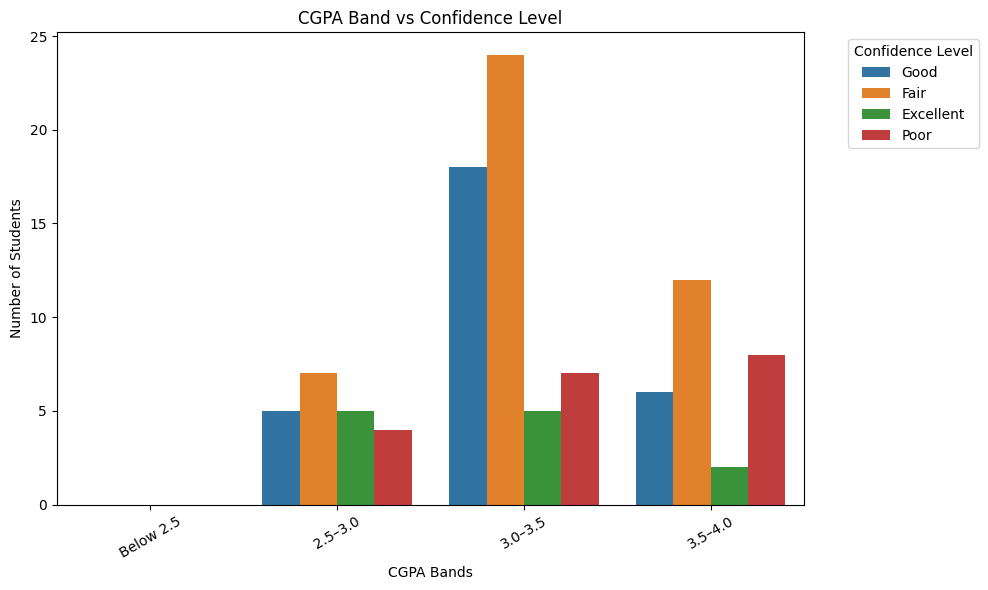

In [7]:
# =============================
# CLEAN COLUMN NAMES
# =============================

df.columns = df.columns.str.strip()

# =============================
# CLEAN CGPA COLUMN
# =============================

df['Current CGPA'] = pd.to_numeric(df['Current CGPA'], errors='coerce')

# =============================
# CREATE CGPA BANDS
# =============================

bins = [0, 2.5, 3.0, 3.5, 4.0]
labels = ['Below 2.5', '2.5–3.0', '3.0–3.5', '3.5–4.0']

df['CGPA Band'] = pd.cut(df['Current CGPA'], bins=bins, labels=labels)

# =============================
# CONFIDENCE COLUMN
# =============================

conf_col = 'Rate according to the following (Learning from University): [How confident are you in getting a job after graduation?]'

# =============================
# CLEAN DATA
# =============================

df = df.dropna(subset=['CGPA Band', conf_col])

# =============================
# PLOT (GROUPED BAR CHART)
# =============================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='CGPA Band',
    hue=conf_col
)

plt.title('CGPA Band vs Confidence Level')
plt.xlabel('CGPA Bands')
plt.ylabel('Number of Students')

plt.xticks(rotation=30)

plt.legend(title='Confidence Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**GRAPH 7 — RADAR CHART: UNIVERSITY LEARNING OUTCOMES**

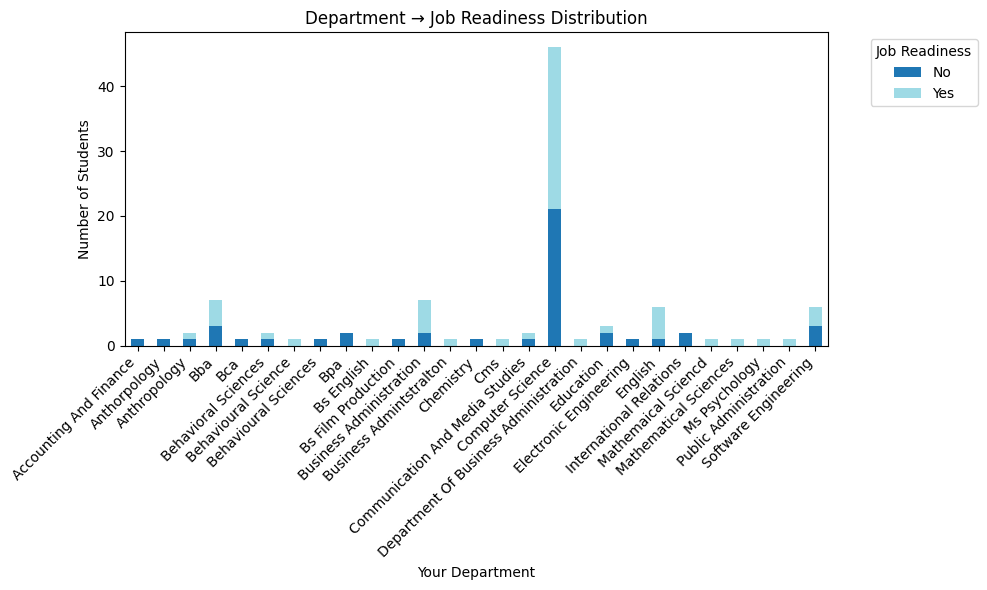

In [8]:
dept_col = 'Your Department:'
job_col = 'Respond to the following Questions. [If you had to judge yourself honestly, do you think you are job-ready after graduation ??]'

# =============================
# CLEAN DATA
# =============================

df2 = df[[dept_col, job_col]].dropna()

# =============================
# GROUP DATA (same logic as sunburst)
# =============================

df_grouped = df2.groupby([dept_col, job_col]).size().reset_index(name='count')

# =============================
# PLOT (STACKED BAR - SUNBURST ALTERNATIVE)
# =============================

pivot_data = df_grouped.pivot(index=dept_col, columns=job_col, values='count').fillna(0)

pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab20'
)

plt.title('Department → Job Readiness Distribution')
plt.xlabel('Your Department')
plt.ylabel('Number of Students')

plt.xticks(rotation=45, ha='right')

plt.legend(title='Job Readiness', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**GRAPH 8 — PARALLEL CATEGORIES: CGPA + INTERNSHIP + JOB READINESS**

/tmp/ipykernel_3330/1202820813.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


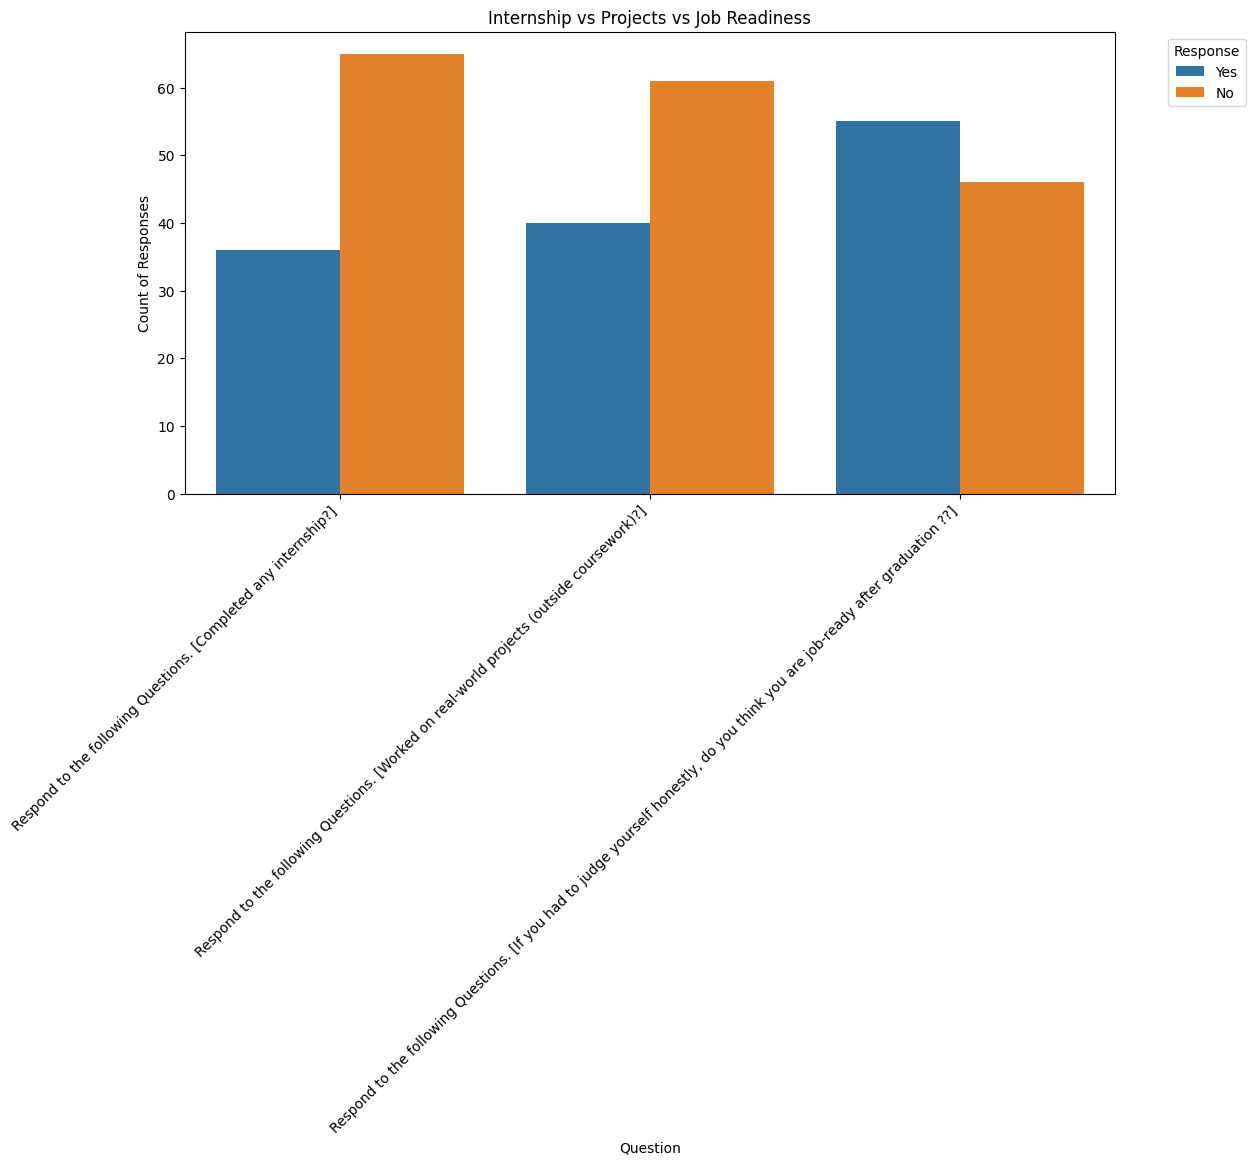

In [9]:
cols = [
    'Respond to the following Questions. [Completed any internship?]',
    'Respond to the following Questions. [Worked on real-world projects (outside coursework)?]',
    'Respond to the following Questions. [If you had to judge yourself honestly, do you think you are job-ready after graduation ??]'
]

# =============================
# CLEAN DATA
# =============================

df2 = df[cols].dropna()

# =============================
# WIDE → LONG FORMAT
# =============================

df_long = df2.melt(var_name='Question', value_name='Response')

# =============================
# PLOT (GROUPED COUNT PLOT)
# =============================

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_long,
    x='Question',
    hue='Response'
)

plt.title('Internship vs Projects vs Job Readiness')
plt.xlabel('Question')
plt.ylabel('Count of Responses')

plt.xticks(rotation=45, ha='right')

plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**GRAPH 9 — FUNNEL CHART: CAREER PREPARATION PIPELINE**

/tmp/ipykernel_3330/2080042466.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


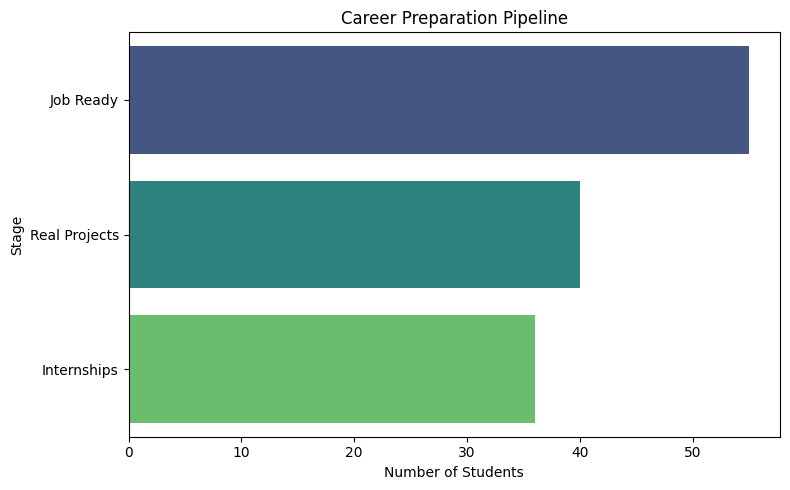

In [10]:
intern_yes = (df['Respond to the following Questions. [Completed any internship?]'] == 'Yes').sum()

project_yes = (df['Respond to the following Questions. [Worked on real-world projects (outside coursework)?]'] == 'Yes').sum()

ready_yes = (df['Respond to the following Questions. [If you had to judge yourself honestly, do you think you are job-ready after graduation ??]'] == 'Yes').sum()

# =============================
# PIPELINE DATAFRAME
# =============================

pipeline_df = pd.DataFrame({
    'Stage': ['Internships', 'Real Projects', 'Job Ready'],
    'Students': [intern_yes, project_yes, ready_yes]
})

# Sort for funnel effect
pipeline_df = pipeline_df.sort_values('Students', ascending=False)

# =============================
# PLOT (FUNNEL SUBSTITUTE)
# =============================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=pipeline_df,
    x='Students',
    y='Stage',
    palette='viridis'
)

plt.title('Career Preparation Pipeline')
plt.xlabel('Number of Students')
plt.ylabel('Stage')

plt.tight_layout()
plt.show()